NYC Taxi Fare Prediction | Machine Learning, Python


Import Libraries

In [2]:

import pandas as pd
import numpy as np


import matplotlib.pyplot as plt


from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)


import joblib


import warnings
warnings.filterwarnings('ignore')

Load Dataset

In [4]:

df = pd.read_csv("nyc_tlc_yellow_2024_01.csv")


df = df.sample(100000, random_state=42)


df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee
1725696,2,2024-01-20 13:31:30,2024-01-20 14:03:25,2.0,17.14,2.0,N,132,233,1,70.0,0.0,0.5,8.27,6.94,1.0,90.96,2.5,1.75
1581136,2,2024-01-18 21:52:46,2024-01-18 22:03:21,1.0,2.49,1.0,N,163,75,1,13.5,1.0,0.5,4.00,0.00,1.0,22.50,2.5,0.00
19137,2,2024-01-01 03:43:58,2024-01-01 03:50:47,2.0,1.84,1.0,N,127,20,2,10.0,1.0,0.5,0.00,0.00,1.0,12.50,0.0,0.00
1682810,1,2024-01-19 22:20:12,2024-01-19 22:50:12,1.0,3.60,1.0,N,186,263,1,23.3,3.5,0.5,5.65,0.00,1.0,33.95,2.5,0.00
511035,2,2024-01-06 22:41:50,2024-01-06 22:43:24,1.0,0.04,1.0,N,238,238,2,3.7,1.0,0.5,0.00,0.00,1.0,6.20,0.0,0.00


Dataset Information

In [6]:
print("Dataset Shape:", df.shape)

df.info()

Dataset Shape: (100000, 19)
<class 'pandas.core.frame.DataFrame'>
Index: 100000 entries, 1725696 to 1247237
Data columns (total 19 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   VendorID               100000 non-null  int64  
 1   tpep_pickup_datetime   100000 non-null  object 
 2   tpep_dropoff_datetime  100000 non-null  object 
 3   passenger_count        95273 non-null   float64
 4   trip_distance          100000 non-null  float64
 5   RatecodeID             95273 non-null   float64
 6   store_and_fwd_flag     95273 non-null   object 
 7   PULocationID           100000 non-null  int64  
 8   DOLocationID           100000 non-null  int64  
 9   payment_type           100000 non-null  int64  
 10  fare_amount            100000 non-null  float64
 11  extra                  100000 non-null  float64
 12  mta_tax                100000 non-null  float64
 13  tip_amount             100000 non-null  float64
 14  tolls_

Check Missing Values

In [8]:
df.isnull().sum()

VendorID                    0
tpep_pickup_datetime        0
tpep_dropoff_datetime       0
passenger_count          4727
trip_distance               0
RatecodeID               4727
store_and_fwd_flag       4727
PULocationID                0
DOLocationID                0
payment_type                0
fare_amount                 0
extra                       0
mta_tax                     0
tip_amount                  0
tolls_amount                0
improvement_surcharge       0
total_amount                0
congestion_surcharge     4727
Airport_fee              4727
dtype: int64

Basic EDA

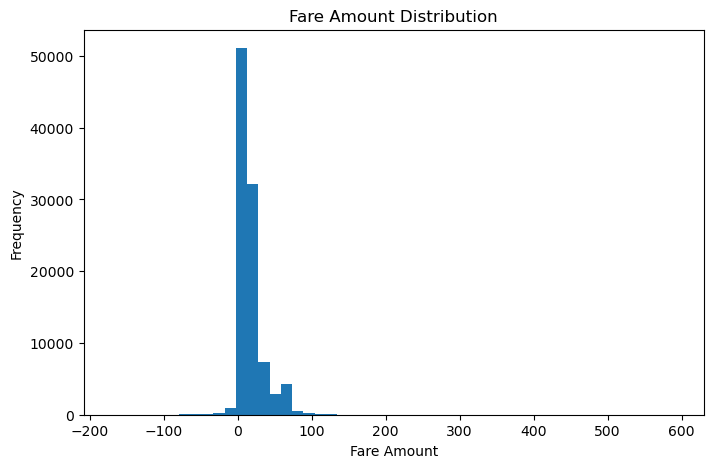

In [10]:
plt.figure(figsize=(8,5))

plt.hist(df['fare_amount'], bins=50)

plt.title("Fare Amount Distribution")
plt.xlabel("Fare Amount")
plt.ylabel("Frequency")

plt.show()

Passenger Count

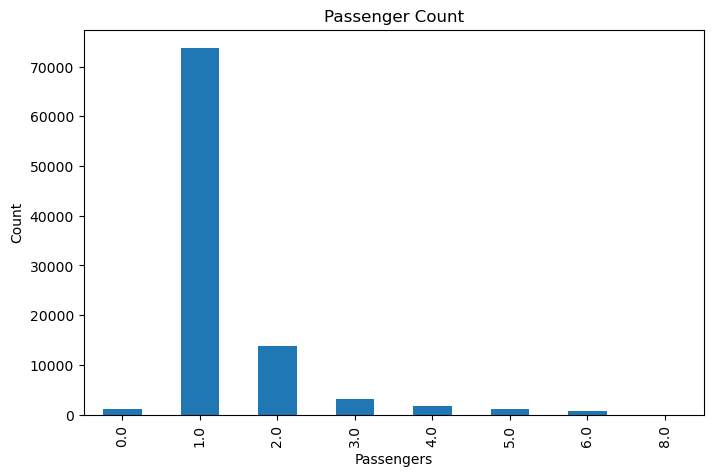

In [12]:
plt.figure(figsize=(8,5))

df['passenger_count'].value_counts().sort_index().plot(kind='bar')

plt.title("Passenger Count")
plt.xlabel("Passengers")
plt.ylabel("Count")

plt.show()

Data Preprocessing

In [14]:
df['tpep_pickup_datetime'] = pd.to_datetime(
    df['tpep_pickup_datetime']
)

In [15]:
# Feature Engineering
df['pickup_hour'] = df['tpep_pickup_datetime'].dt.hour
df['pickup_day'] = df['tpep_pickup_datetime'].dt.day
df['pickup_month'] = df['tpep_pickup_datetime'].dt.month

In [16]:
df.drop(
    columns=[
        'tpep_pickup_datetime',
        'tpep_dropoff_datetime',
        'store_and_fwd_flag'
    ],
    inplace=True
)

Remove Missing Values

In [18]:
df.dropna(inplace=True)

df.isnull().sum()

VendorID                 0
passenger_count          0
trip_distance            0
RatecodeID               0
PULocationID             0
DOLocationID             0
payment_type             0
fare_amount              0
extra                    0
mta_tax                  0
tip_amount               0
tolls_amount             0
improvement_surcharge    0
total_amount             0
congestion_surcharge     0
Airport_fee              0
pickup_hour              0
pickup_day               0
pickup_month             0
dtype: int64

Define Features and Target

In [20]:

X = df.drop('fare_amount', axis=1)


y = df['fare_amount']

Train-Test Split

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (76218, 18)
Testing Shape: (19055, 18)


Linear Regression Model

In [24]:
# Model
lr_model = LinearRegression()

# Train
lr_model.fit(X_train, y_train)

# Prediction
lr_pred = lr_model.predict(X_test)

Random Forest Model

In [26]:

rf_model = RandomForestRegressor(
    n_estimators=50,
    random_state=42
)

# Train
rf_model.fit(X_train, y_train)

# Prediction
rf_pred = rf_model.predict(X_test)

Model Evaluation Function

In [28]:
def evaluate_model(y_true, y_pred, model_name):

    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    print(f"\n{model_name}")
    print("-" * 30)
    print("MAE :", mae)
    print("RMSE:", rmse)
    print("R2 Score:", r2)

Evaluate Models

In [30]:
evaluate_model(
    y_test,
    lr_pred,
    "Linear Regression"
)

evaluate_model(
    y_test,
    rf_pred,
    "Random Forest"
)


Linear Regression
------------------------------
MAE : 0.08828729064400913
RMSE: 0.2504450697659258
R2 Score: 0.9998134587630794

Random Forest
------------------------------
MAE : 0.22130749934400964
RMSE: 1.3768092659975677
R2 Score: 0.9943623587108971


Feature Importance

In [32]:
importance = rf_model.feature_importances_

feature_names = X.columns

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance
})

importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

importance_df

,Feature,Importance
12,total_amount,9.557083e-01
2,trip_distance,2.208884e-02
9,tip_amount,9.681045e-03
3,RatecodeID,5.994798e-03
7,extra,2.060510e-03
10,tolls_amount,1.618810e-03
15,pickup_hour,8.768247e-04
5,DOLocationID,4.236524e-04
16,pickup_day,3.297383e-04
4,PULocationID,3.213873e-04


Feature Importance Graph

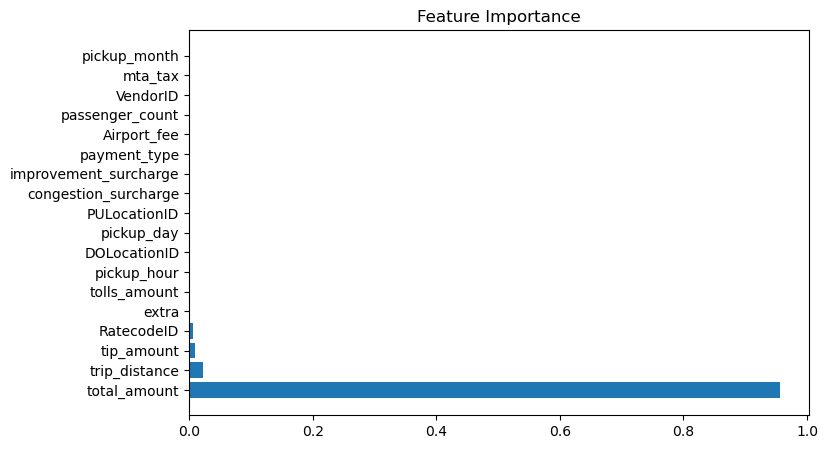

In [34]:
plt.figure(figsize=(8,5))

plt.barh(
    importance_df['Feature'],
    importance_df['Importance']
)

plt.title("Feature Importance")

plt.show()

Actual vs Predicted Graph

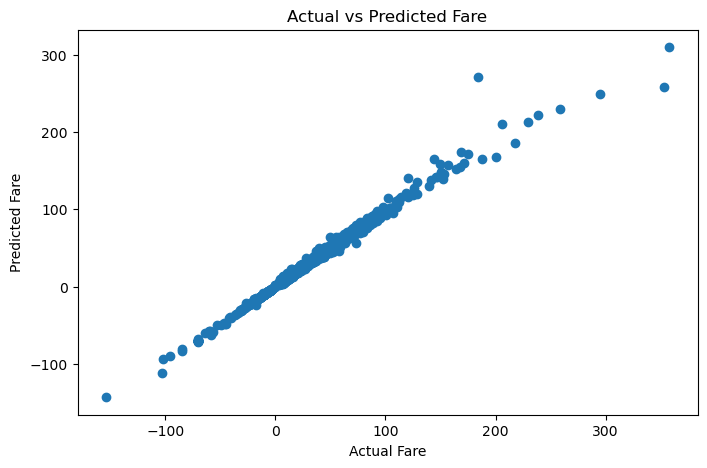

In [36]:
plt.figure(figsize=(8,5))

plt.scatter(y_test, rf_pred)

plt.xlabel("Actual Fare")
plt.ylabel("Predicted Fare")

plt.title("Actual vs Predicted Fare")

plt.show()

Save Model

In [38]:
joblib.dump(
    rf_model,
    "taxi_fare_prediction_model.pkl"
)

print("Model Saved Successfully!")

Model Saved Successfully!
